# **Reto: Analítica de textos**

In [ ]:
!pip install -U pysentimiento

In [ ]:
!pip install accelerate -U

In [ ]:
!pip install transformers[torch] #dependencia de matrices, torch

In [ ]:
# Importar las bibliotecas

import pandas as pd
import regex as re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.corpus import wordnet
from pysentimiento import create_analyzer
import matplotlib.pyplot as plt
import string
from collections import Counter

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
corpus = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data Science and AI/Undécima sesión/stockerbot-export.csv', sep = ',', on_bad_lines = 'skip')

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
def quita_puntuacion(texto):
    traductor = str.maketrans(str.maketrans('','', string.punctuation))
    return texto.translate(traductor)

In [ ]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [ ]:
import emoji

def elimina_emojis(texto):
    return emoji.replace_emoji(texto, replace = '')

In [ ]:
def elimina_numeros(cadena):
    # Reemplaza todos los dígitos (\d) en la cadena por una cadena vacía
    return re.sub(r'\d+', '', cadena)

In [ ]:
def tokeniza(texto):
    return re.findall("[\w-]+\p{L}[\w-]+", texto)

In [ ]:
vtexto = corpus['text'].str.lower().apply(tokeniza)

In [ ]:
def quita_sw(vpalabras, idioma = "english"):
    return [palabra for palabra in vpalabras if palabra not in stopwords.words(idioma)]

In [ ]:
vtexto = quita_sw(vtexto)

In [ ]:
print(vtexto)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
corpus.isnull().sum()

,0
id,0
text,0
timestamp,0
source,0
symbols,0
company_names,1
url,6369
verified,0


In [ ]:
# Eliminar valores nulos
corpus.dropna(inplace = True)

In [ ]:
corpus = corpus.drop(columns = ['id', 'timestamp', 'symbols', 'url'])
corpus = corpus.drop_duplicates()

In [ ]:
corpus['cleaned_text'] = corpus['text'].apply(quita_puntuacion)
corpus['cleaned_text'] = corpus['cleaned_text'].apply(elimina_emojis)
corpus['cleaned_text'] = corpus['cleaned_text'].apply(elimina_numeros)
display(corpus[['text', 'cleaned_text']].head())

,text,cleaned_text
0,VIDEO: “I was in my office. I was minding my o...,VIDEO “I was in my office I was minding my own...
1,The price of lumber $LB_F is down 22% since hi...,The price of lumber LBF is down since hitting...
2,Who says the American Dream is dead? https://t...,Who says the American Dream is dead httpstcoCR...
3,Barry Silbert is extremely optimistic on bitco...,Barry Silbert is extremely optimistic on bitco...
4,How satellites avoid attacks and space junk wh...,How satellites avoid attacks and space junk wh...


In [ ]:
all_words = [word for word_list in vtexto for word in word_list]
word_counts = Counter(all_words)
display(word_counts.most_common(50)) # Display the 20 most common words

[('https', 27536),
 ('for', 6133),
 ('the', 5502),
 ('inc', 4086),
 ('amp', 3013),
 ('and', 2677),
 ('earnings', 1952),
 ('stock', 1827),
 ('price', 1766),
 ('analysts', 1696),
 ('has', 1486),
 ('this', 1457),
 ('eps', 1447),
 ('with', 1366),
 ('from', 1365),
 ('new', 1210),
 ('group', 1144),
 ('buy', 1105),
 ('expected', 1093),
 ('binance', 1093),
 ('today', 1081),
 ('short', 1058),
 ('stocks', 1055),
 ('register', 1001),
 ('are', 984),
 ('bonus', 960),
 ('you', 946),
 ('million', 937),
 ('join', 921),
 ('options', 919),
 ('high', 888),
 ('rating', 854),
 ('target', 853),
 ('trading', 847),
 ('share', 844),
 ('our', 823),
 ('its', 809),
 ('shares', 792),
 ('after', 789),
 ('investment', 780),
 ('will', 771),
 ('energy', 761),
 ('jul', 742),
 ('corp', 741),
 ('get', 739),
 ('corporation', 727),
 ('week', 716),
 ('zacks', 709),
 ('out', 699),
 ('top', 695)]

<Figure size 1000x600 with 0 Axes>

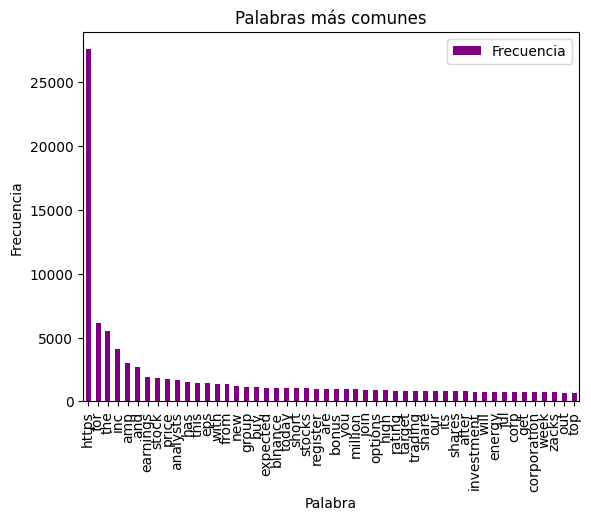

In [ ]:
# Graficar palabras más comunes

word_counts = Counter(all_words)

mas_comunes = word_counts.most_common(50)
df_comunes = pd.DataFrame(mas_comunes, columns = ['Palabra', 'Frecuencia'])

plt.figure(figsize = (10, 6))
df_comunes.plot(kind = 'bar', x = 'Palabra', y = 'Frecuencia', color = 'purple')
plt.title('Palabras más comunes')
plt.xlabel('Palabra')
plt.ylabel('Frecuencia')
plt.xticks(rotation = 90)
plt.show()

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


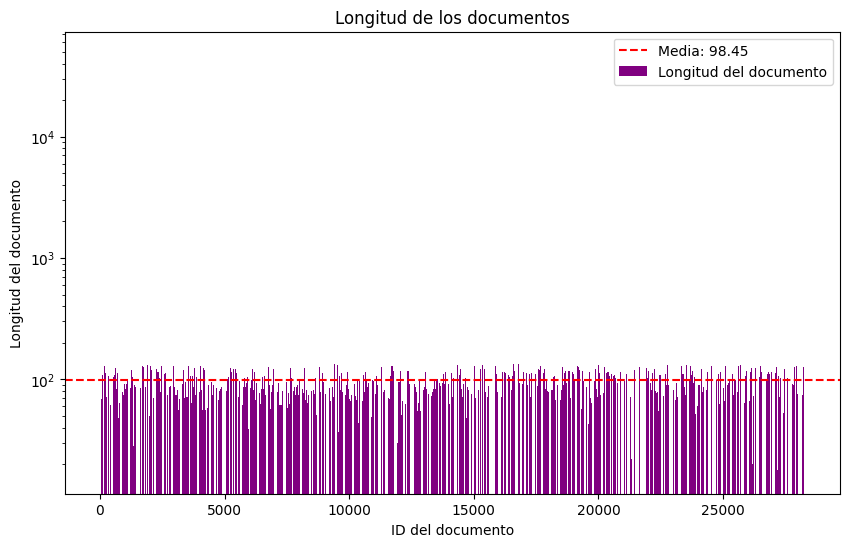

In [ ]:
# Calcular la media de longitud
media_longitud = corpus['cleaned_text'].apply(len).mean()

# Graficar
plt.figure(figsize = (10, 6))
plt.bar(corpus.index, corpus['cleaned_text'].apply(len), color = 'purple', label = 'Longitud del documento')
plt.axhline(media_longitud, color = 'red', linestyle = '--', label = f'Media: {media_longitud:.2f}')

plt.xlabel('ID del documento')
plt.ylabel('Longitud del documento')
plt.yscale('log')
plt.title('Longitud de los documentos')
plt.legend()
plt.show()

In [ ]:
corpus["tokens_regex"] = corpus["cleaned_text"].apply(tokeniza)

In [ ]:
corpus.head()

,text,source,company_names,verified,cleaned_text,tokens_regex
0,VIDEO: “I was in my office. I was minding my o...,GoldmanSachs,The Goldman Sachs,True,VIDEO “I was in my office I was minding my own...,"[VIDEO, was, office, was, minding, own, busine..."
1,The price of lumber $LB_F is down 22% since hi...,StockTwits,Macy's,True,The price of lumber LBF is down since hitting...,"[The, price, lumber, LBF, down, since, hitting..."
2,Who says the American Dream is dead? https://t...,TheStreet,American,True,Who says the American Dream is dead httpstcoCR...,"[Who, says, the, American, Dream, dead, httpst..."
3,Barry Silbert is extremely optimistic on bitco...,MarketWatch,Bitcoin,True,Barry Silbert is extremely optimistic on bitco...,"[Barry, Silbert, extremely, optimistic, bitcoi..."
4,How satellites avoid attacks and space junk wh...,Forbes,Oracle,True,How satellites avoid attacks and space junk wh...,"[How, satellites, avoid, attacks, and, space, ..."


In [ ]:
corpus["ntokens_regex"] = corpus.tokens_regex.apply(lambda x: len(x))

In [ ]:
corpus.head()

,text,source,company_names,verified,cleaned_text,tokens_regex,ntokens_regex
0,VIDEO: “I was in my office. I was minding my o...,GoldmanSachs,The Goldman Sachs,True,VIDEO “I was in my office I was minding my own...,"[VIDEO, was, office, was, minding, own, busine...",14
1,The price of lumber $LB_F is down 22% since hi...,StockTwits,Macy's,True,The price of lumber LBF is down since hitting...,"[The, price, lumber, LBF, down, since, hitting...",16
2,Who says the American Dream is dead? https://t...,TheStreet,American,True,Who says the American Dream is dead httpstcoCR...,"[Who, says, the, American, Dream, dead, httpst...",7
3,Barry Silbert is extremely optimistic on bitco...,MarketWatch,Bitcoin,True,Barry Silbert is extremely optimistic on bitco...,"[Barry, Silbert, extremely, optimistic, bitcoi...",15
4,How satellites avoid attacks and space junk wh...,Forbes,Oracle,True,How satellites avoid attacks and space junk wh...,"[How, satellites, avoid, attacks, and, space, ...",15


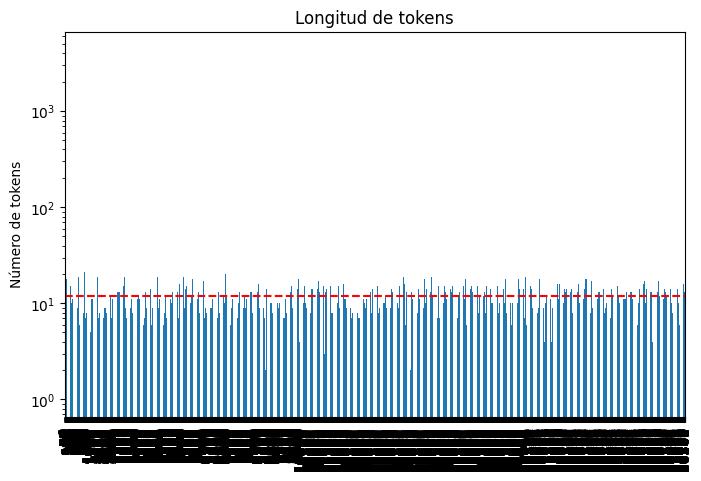

In [ ]:
# Calcular la media de longitud
media_longitud = corpus['ntokens_regex'].mean()

# Gráfica rápida usando pandas
ax = corpus['ntokens_regex'].plot(kind = 'bar', figsize = (8, 5), title = 'Longitud de tokens')
plt.axhline(media_longitud, color = 'red', linestyle = '--', label = f'Media = {media_longitud:.2f}')
plt.ylabel('Número de tokens')
plt.yscale('log')
plt.show()

In [ ]:
from wordcloud import WordCloud
from PIL import Image
import numpy as np

def nube_palabras(corpus, stopwords, color):
    stopwords = set(stopwords)
    wordcloud = WordCloud(
        background_color = color,
        stopwords = stopwords,
        max_words = 100,
        max_font_size = 50,
        random_state = 1,
        collocations = False)

    wordcloud=wordcloud.generate(str(corpus))

    fig = plt.figure(1, figsize = (15, 15))
    plt.imshow(wordcloud)
    plt.axis('on')
    plt.show()

In [ ]:
cadena = " ".join(token for vector_sstop in corpus.tokens_regex for token in vector_sstop )

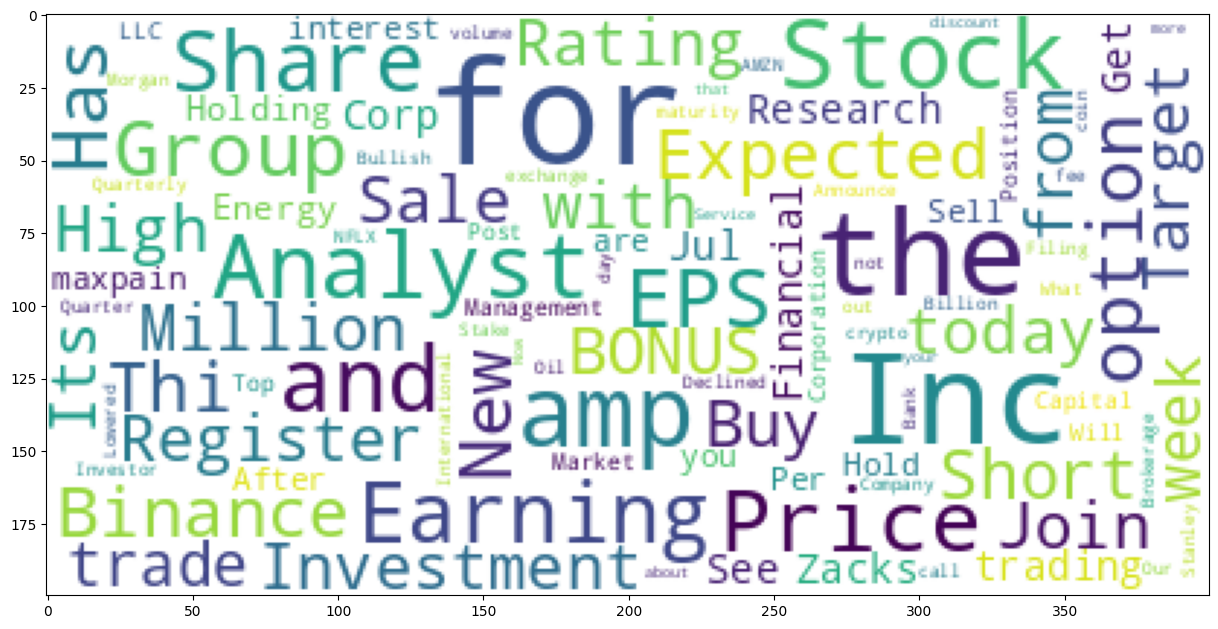

In [ ]:
nube_palabras(cadena, ["br"], "white")

# **Lematización**

In [ ]:
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
# Crear el lematizador
lemmatizer = WordNetLemmatizer()

# Ejemplos de lematización
print("Lematización de 'running' (verbo): ", lemmatizer.lemmatize("running", pos = "v"))  # Verbo
print("Lematización de 'better' (adjetivo): ", lemmatizer.lemmatize("better", pos = "a"))  # Adjetivo
print("Lematización de 'geese' (sustantivo): ", lemmatizer.lemmatize("geese", pos = "n"))  # Sustantivo

Lematización de 'running' (verbo):  run
Lematización de 'better' (adjetivo):  good
Lematización de 'geese' (sustantivo):  goose


In [ ]:
def lematiza(vtexto):
    return [lemmatizer.lemmatize(token) for token in vtexto]

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(corpus['cleaned_text'])

df = pd.DataFrame(X.toarray(), columns = vectorizer.get_feature_names_out())

pd.set_option('display.max_columns', None)
df.shape

(21793, 39895)

In [ ]:
df.head()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X = corpus['cleaned_text']
y = corpus['verified']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

tfidf = TfidfVectorizer(stop_words = 'english', max_df = 0.7)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(17434, 34094)
(4359, 34094)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf.fit(X_train_tfidf, y_train)

RandomForestClassifier(random_state=42)

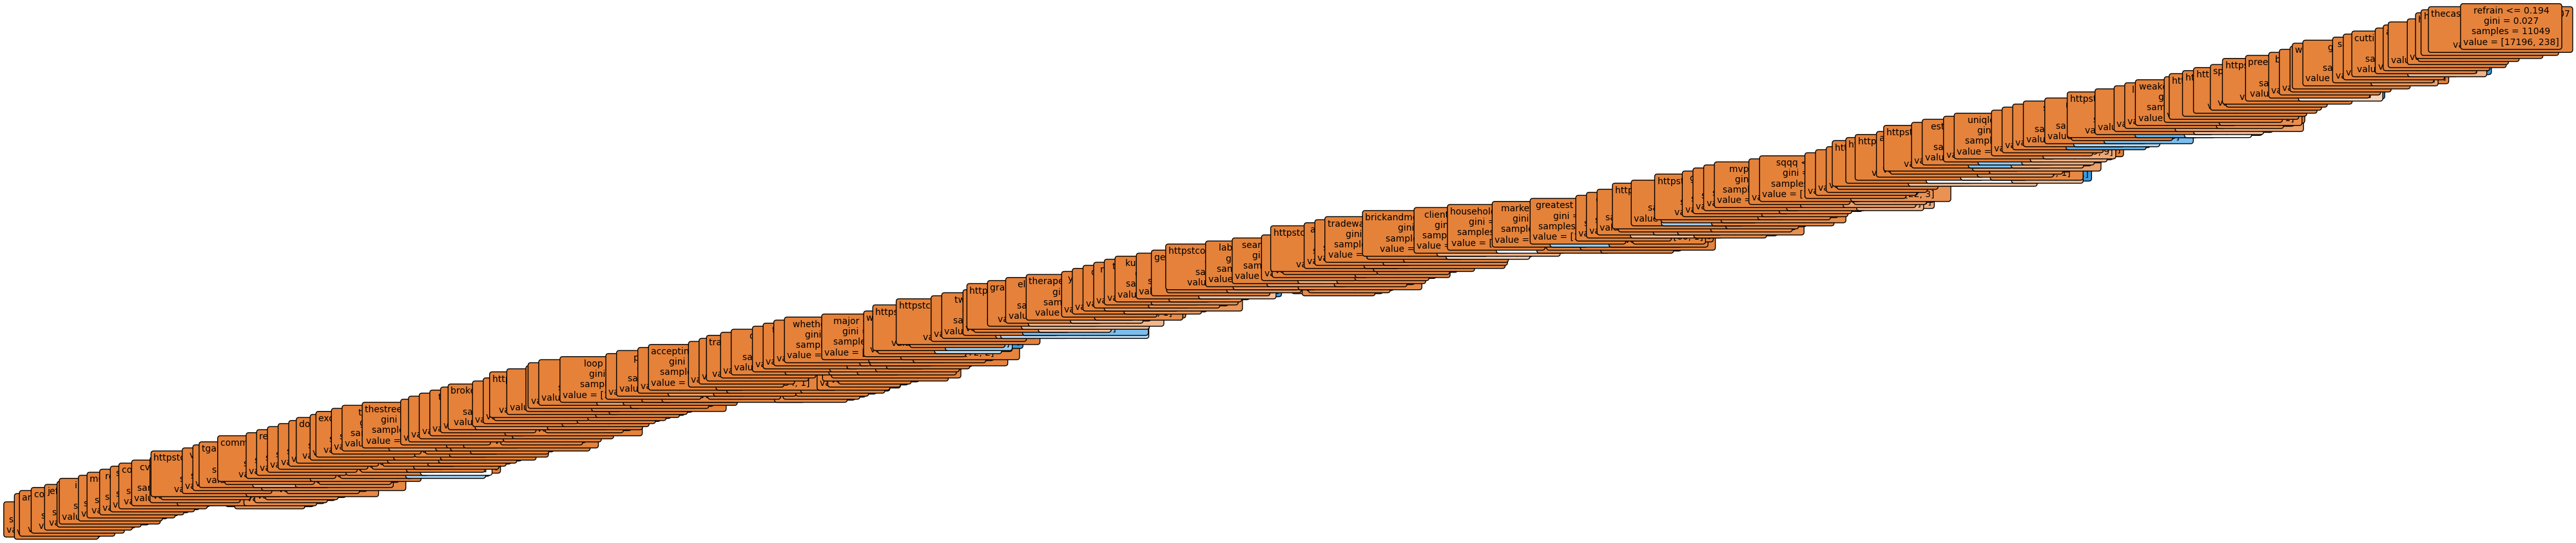

In [ ]:
from sklearn.tree import export_text, plot_tree

plt.figure(figsize = (50, 10))
class_names_str = [str(c) for c in rf.classes_]
plot_tree(rf.estimators_[0], feature_names = tfidf.get_feature_names_out(), filled = True, rounded = True, fontsize = 10)
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = rf.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9892177104840559


In [ ]:
review_x = ["the US goverment is losing money"]
review_x_tfidf = tfidf.transform(review_x)
print(rf.predict(review_x_tfidf))

[False]
